# Cross-City LVT Analysis

Loads standardized CSVs from all cities and compares LVT impacts.
No modeling or API calls — just reads `analysis/data/*.csv`.

Run after running each city's `model.ipynb` to update the CSVs.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from lvt.style import apply_lvt_style, CATEGORY_COLORS, INCREASE_COLOR, DECREASE_COLOR
apply_lvt_style()

DATA_DIR = Path('data')

# Load all city CSVs
dfs = []
for csv_path in sorted(DATA_DIR.glob('*.csv')):
    if csv_path.name == '.gitkeep':
        continue
    try:
        df = pd.read_csv(csv_path)
        dfs.append(df)
        print(f'  {csv_path.stem}: {len(df):,} rows')
    except Exception as e:
        print(f'  ERROR {csv_path.stem}: {e}')

if not dfs:
    raise RuntimeError('No city CSVs found in analysis/data/. Run city notebooks first.')

all_cities = pd.concat(dfs, ignore_index=True)
print(f'\nTotal: {len(all_cities):,} parcels across {all_cities["city"].nunique()} cities')
print(all_cities['city'].value_counts().to_string())

  minneapolis: 122,736 rows
  st_paul: 72,437 rows

Total: 195,173 parcels across 2 cities
city
minneapolis    122736
st_paul         72437


## 1. Revenue and Parcel Summary

In [2]:
# Revenue and parcel count summary by city
summary = all_cities.groupby('city').agg(
    parcel_count=('current_tax', 'count'),
    taxable_parcels=('current_tax', lambda x: (x > 0).sum()),
    current_revenue=('current_tax', 'sum'),
    new_revenue=('new_tax', 'sum'),
    model_type=('model_type', 'first'),
    land_millage=('land_millage', 'first'),
    improvement_millage=('improvement_millage', 'first'),
).reset_index()

summary['revenue_neutral_pct'] = (
    (summary['new_revenue'] - summary['current_revenue']).abs() /
    summary['current_revenue'] * 100
).round(3)

summary['current_revenue_M'] = (summary['current_revenue'] / 1e6).round(1)
summary['new_revenue_M'] = (summary['new_revenue'] / 1e6).round(1)

display_cols = [
    'city', 'parcel_count', 'taxable_parcels', 'current_revenue_M',
    'new_revenue_M', 'revenue_neutral_pct', 'model_type', 'land_millage', 'improvement_millage'
]
print(summary[display_cols].to_string(index=False))

       city  parcel_count  taxable_parcels  current_revenue_M  new_revenue_M  revenue_neutral_pct     model_type  land_millage  improvement_millage
minneapolis        122736           122736             1174.0         1174.0                  0.0 split_rate:4.0   3377.492034           844.373008
    st_paul         72437            72399              647.7          647.7                  0.0 split_rate:4.0   4125.720851          1031.430213


## 2. Tax Change Distribution by City

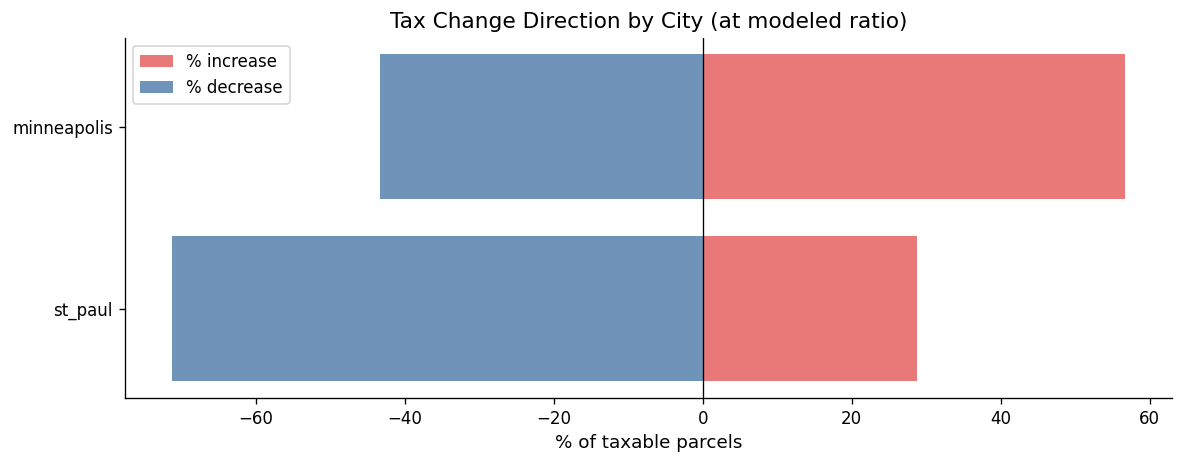

       city  pct_increase  pct_decrease  median_change_pct
    st_paul     28.757303     71.242697         -12.878358
minneapolis     56.654119     43.345881           6.489745


In [3]:
# % parcels with tax increase, by city (excluding zero-tax parcels)
taxable = all_cities[all_cities['current_tax'] > 0].copy()

direction = taxable.groupby('city').agg(
    pct_increase=('tax_change', lambda x: (x > 0).mean() * 100),
    pct_decrease=('tax_change', lambda x: (x < 0).mean() * 100),
    median_change_pct=('tax_change_pct', 'median'),
).reset_index().sort_values('pct_increase')

fig, ax = plt.subplots(figsize=(10, max(4, len(direction) * 0.5)))
cities = direction['city']
y = range(len(cities))
ax.barh(y, direction['pct_increase'], color=INCREASE_COLOR, alpha=0.8, label='% increase')
ax.barh(y, -direction['pct_decrease'], color=DECREASE_COLOR, alpha=0.8, label='% decrease')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(list(y))
ax.set_yticklabels(cities)
ax.set_xlabel('% of taxable parcels')
ax.set_title('Tax Change Direction by City (at modeled ratio)')
ax.legend()
plt.tight_layout()
plt.show()

print(direction.to_string(index=False))

## 3. Property Category Comparison

Median tax change % by category and city:
property_category  Commercial  Large Multi-Family (5+ units)  Single Family Residential  Small Multi-Family (2-4 units)  Vacant Land
city                                                                                                                                
minneapolis             -11.8                          -20.4                       16.1                             3.7        122.3
st_paul                   5.7                            3.5                      -14.0                           -17.3        145.8


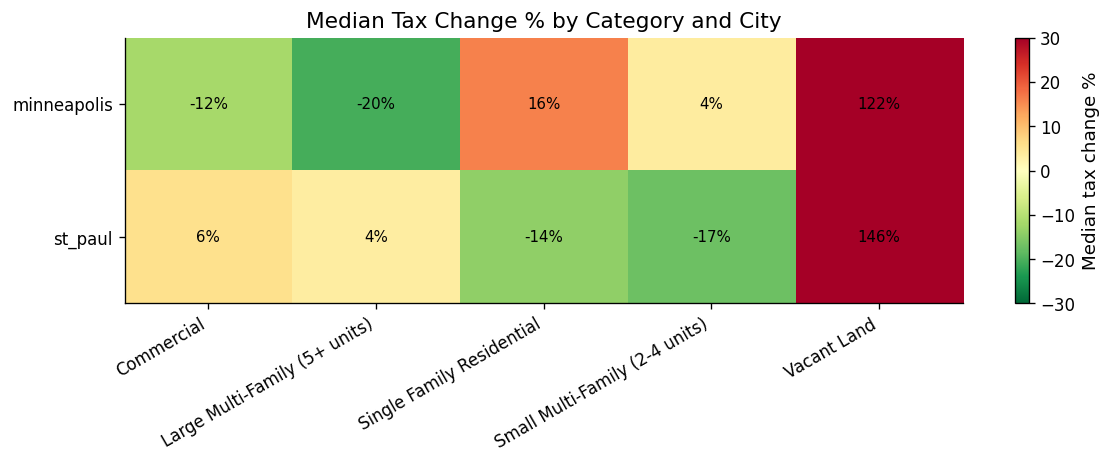

In [4]:
# Median tax change % by property category × city
# Focus on the most common standard categories
focus_cats = [
    'Single Family Residential',
    'Commercial',
    'Vacant Land',
    'Large Multi-Family (5+ units)',
    'Small Multi-Family (2-4 units)',
]

cat_city = (
    taxable[taxable['property_category'].isin(focus_cats)]
    .groupby(['city', 'property_category'])
    ['tax_change_pct']
    .median()
    .unstack('property_category')
    .round(1)
)

print('Median tax change % by category and city:')
print(cat_city.to_string())

# Heatmap
if len(cat_city) > 1:
    fig, ax = plt.subplots(figsize=(max(8, len(cat_city.columns) * 2), max(4, len(cat_city) * 0.6)))
    im = ax.imshow(cat_city.values, cmap='RdYlGn_r', aspect='auto', vmin=-30, vmax=30)
    ax.set_xticks(range(len(cat_city.columns)))
    ax.set_xticklabels(cat_city.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(cat_city.index)))
    ax.set_yticklabels(cat_city.index)
    plt.colorbar(im, ax=ax, label='Median tax change %')
    ax.set_title('Median Tax Change % by Category and City')
    for i in range(len(cat_city.index)):
        for j in range(len(cat_city.columns)):
            val = cat_city.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

## 4. Income Quintile Equity Comparison

/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_44370/317818389.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  with_census.groupby(['city', 'income_quintile'])


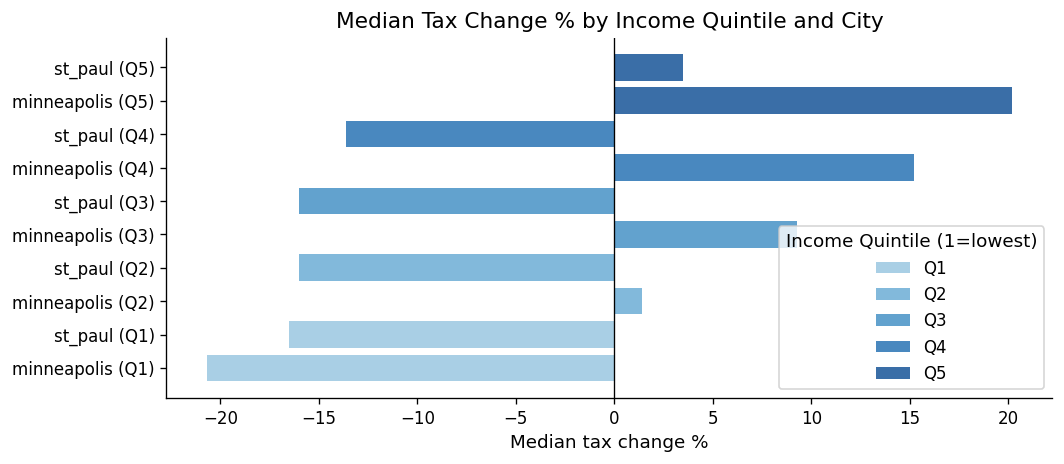

income_quintile     1     2     3     4     5
city                                         
minneapolis     -20.7   1.4   9.3  15.2  20.2
st_paul         -16.5 -16.0 -16.0 -13.6   3.5


In [5]:
# Income quintile analysis: median tax change % in each quintile, by city
# Only cities with Census data
with_census = all_cities[all_cities['median_income'].notna() & (all_cities['current_tax'] > 0)].copy()

if len(with_census) == 0:
    print('No Census data available yet. Run city notebooks with Census API key to populate.')
else:
    # Assign income quintile within each city
    with_census['income_quintile'] = with_census.groupby('city')['median_income'].transform(
        lambda x: pd.qcut(x, 5, labels=[1, 2, 3, 4, 5], duplicates='drop')
    )

    quintile_city = (
        with_census.groupby(['city', 'income_quintile'])
        ['tax_change_pct']
        .median()
        .unstack('income_quintile')
        .round(1)
    )

    fig, ax = plt.subplots(figsize=(9, max(4, len(quintile_city) * 0.7)))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, 5))
    for q, color in zip([1, 2, 3, 4, 5], colors):
        if q in quintile_city.columns:
            ax.barh(
                [f'{c} (Q{q})' for c in quintile_city.index],
                quintile_city[q],
                label=f'Q{q}',
                color=color,
                alpha=0.8,
            )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Median tax change %')
    ax.set_title('Median Tax Change % by Income Quintile and City')
    ax.legend(title='Income Quintile (1=lowest)')
    plt.tight_layout()
    plt.show()

    print(quintile_city.to_string())

## 5. Minority Quintile Equity Comparison

In [6]:
# Minority quintile analysis: same structure as income quintile
with_census_m = all_cities[all_cities['minority_pct'].notna() & (all_cities['current_tax'] > 0)].copy()

if len(with_census_m) == 0:
    print('No Census minority data available yet.')
else:
    with_census_m['minority_quintile'] = with_census_m.groupby('city')['minority_pct'].transform(
        lambda x: pd.qcut(x, 5, labels=[1, 2, 3, 4, 5], duplicates='drop')
    )

    min_quintile_city = (
        with_census_m.groupby(['city', 'minority_quintile'])
        ['tax_change_pct']
        .median()
        .unstack('minority_quintile')
        .round(1)
    )

    print('Median tax change % by minority quintile and city (Q1=least minority, Q5=most minority):')
    print(min_quintile_city.to_string())

Median tax change % by minority quintile and city (Q1=least minority, Q5=most minority):
minority_quintile     1     2     3     4     5
city                                           
minneapolis        20.3  18.0   1.9   4.4 -22.2
st_paul             2.9  -2.9 -15.8 -19.2 -18.6


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_44370/54864268.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  with_census_m.groupby(['city', 'minority_quintile'])
